In [17]:
import pandas as pd
import pickle
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge
from pathlib import Path
from sklearn.metrics import root_mean_squared_error
import mlflow
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials
from hyperopt.pyll import scope
import hyperopt
import xgboost as xgb

mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment("nyc-taxi-experiment")

<Experiment: artifact_location='file:///c:/Users/urbii/Desktop/Projekty/mlops-zoomcamp/02-experiment-tracking/mlruns/1', creation_time=1720033089110, experiment_id='1', last_update_time=1720033089110, lifecycle_stage='active', name='nyc-taxi-experiment', tags={}>

In [2]:
df = pd.read_parquet('green_tripdata_2021-01.parquet')

df['duration'] = df.lpep_dropoff_datetime - df.lpep_pickup_datetime
df.duration = df.duration.apply(lambda td: td.total_seconds() / 60)

df = df[(df.duration >= 1) & (df.duration <= 60)]

categorical = ['PULocationID', 'DOLocationID']
numerical = ['trip_distance']

df[categorical] = df[categorical].astype(str)

In [3]:
train_dicts = df[categorical + numerical].to_dict(orient='records')

dv = DictVectorizer()
X_train = dv.fit_transform(train_dicts)

target = 'duration'
y_train = df[target].values

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_train)

root_mean_squared_error(y_train, y_pred)

9.838799799829628

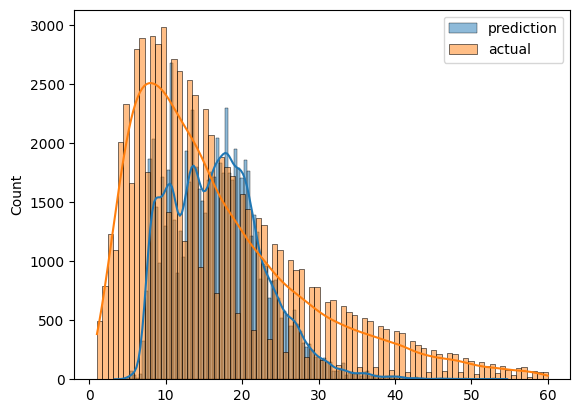

In [4]:
sns.histplot(y_pred, label='prediction', kde=True)
sns.histplot(y_train, label='actual', kde=True)

plt.legend()

In [5]:
def read_dataframe(filename):
    if filename.endswith('.csv'):
        df = pd.read_csv(filename)

        df.lpep_dropoff_datetime = pd.to_datetime(df.lpep_dropoff_datetime)
        df.lpep_pickup_datetime = pd.to_datetime(df.lpep_pickup_datetime)
    elif filename.endswith('.parquet'):
        df = pd.read_parquet(filename)

    df['duration'] = df.lpep_dropoff_datetime - df.lpep_pickup_datetime
    df.duration = df.duration.apply(lambda td: td.total_seconds() / 60)

    df = df[(df.duration >= 1) & (df.duration <= 60)]

    categorical = ['PULocationID', 'DOLocationID']
    df[categorical] = df[categorical].astype(str)
    
    return df

In [6]:
df_train = read_dataframe('green_tripdata_2021-01.parquet')
df_val = read_dataframe('green_tripdata_2021-02.parquet')
len(df_train), len(df_val)

(73908, 61921)

In [7]:
df_train['PU_DO'] = df_train['PULocationID'] + '_' + df_train['DOLocationID']
df_val['PU_DO'] = df_val['PULocationID'] + '_' + df_val['DOLocationID']
categorical = ['PU_DO'] #'PULocationID', 'DOLocationID']
numerical = ['trip_distance']

dv = DictVectorizer()

train_dicts = df_train[categorical + numerical].to_dict(orient='records')
X_train = dv.fit_transform(train_dicts)

val_dicts = df_val[categorical + numerical].to_dict(orient='records')
X_val = dv.transform(val_dicts)

In [8]:
target = 'duration'
y_train = df_train[target].values
y_val = df_val[target].values

In [9]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_val)

root_mean_squared_error(y_val, y_pred)

7.758715205596356

In [21]:
with open('models/lin_reg.bin', 'wb') as f_out:
    pickle.dump((dv, lr), f_out)

### Log some basic metrics with mlflow

In [36]:
with mlflow.start_run():

    mlflow.set_tag("developer", "Kacper")
    mlflow.log_param("train-data-path", "green_tripdata_2021-01.parquet")
    mlflow.log_param("valid-data-path", "green_tripdata_2021-02.parquet")

    alpha = 0.01

    mlflow.log_param("alpha", alpha)
    ls = Lasso(alpha)
    ls.fit(X_train, y_train)

    y_pred = ls.predict(X_val)

    rmse = root_mean_squared_error(y_val, y_pred)
    mlflow.log_metric("rmse", rmse)
    mlflow.log_artifact(local_path='models/lin_reg.bin', artifact_path='models_pickle')

2024/07/04 16:59:03 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'numpy.ndarray' object has no attribute 'toarray'


### Hyperparameter tunning with hyperopt

In [29]:
train = xgb.DMatrix(X_train, y_train)
valid = xgb.DMatrix(X_val, y_val)

def objective(params):
    with mlflow.start_run():
        mlflow.set_tag("model", "xgboost")
        mlflow.log_params(params)
        booster = xgb.train(
            params=params,
            dtrain=train,
            num_boost_round=1000,
            evals=[(valid, 'validation')],
            early_stopping_rounds=50
        )
        y_pred = booster.predict(valid)
        rmse = root_mean_squared_error(y_val, y_pred)
        mlflow.log_metric("rmse", rmse)

    return {'loss': rmse, 'status': STATUS_OK}

In [30]:
search_space = {
    'max_depth': scope.int(hp.quniform('max_depth', 4, 100, 1)),
    'learning_rate': hp.loguniform('learning_rate', -3, 0),
    'reg_alpha': hp.loguniform('reg_alpha', -5, -1),
    'reg_lambda': hp.loguniform('reg_lambda', -6, -1),
    'min_child_weight': hp.loguniform('min_child_weight', -1, 3),
    'objective': 'reg:linear',
    'seed': 42
}

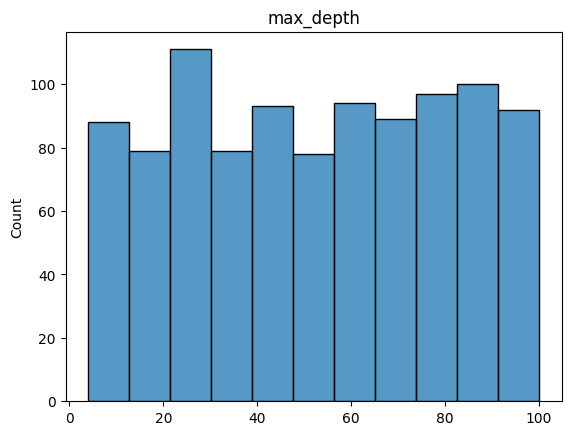

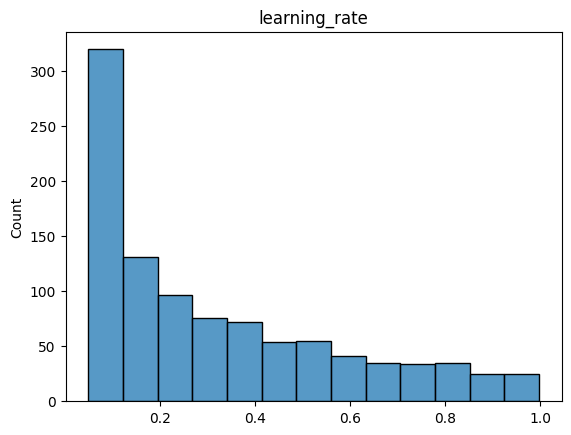

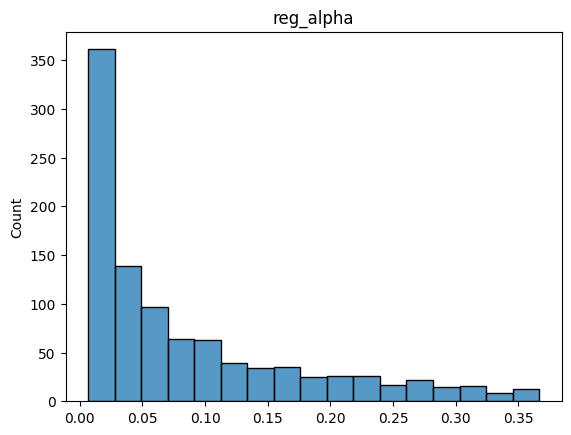

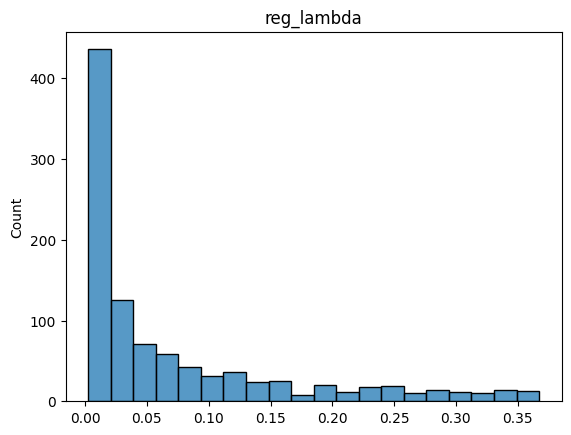

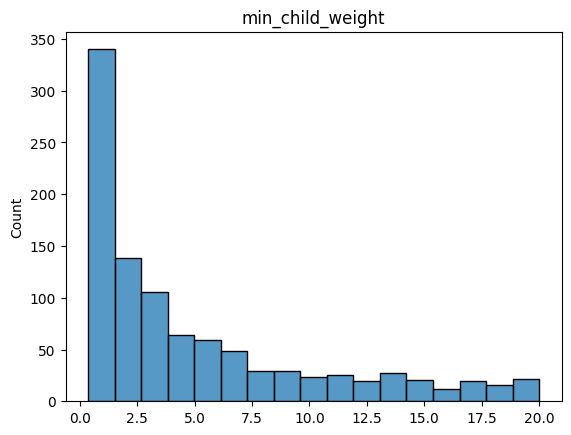

In [31]:
for key, item in search_space.items():
    if key != 'objective' and key != 'seed':
        values = []
        plt.title(key)
        for i in range(1000):
            values.append(hyperopt.pyll.stochastic.sample(item))
        sns.histplot(values)
        plt.show()

In [32]:
best_result = fmin(
    fn=objective,
    space=search_space,
    algo=tpe.suggest,
    max_evals=50,
    trials=Trials()
)

[84]	validation-rmse:6.59458                                                     
[85]	validation-rmse:6.59415                                                     
[86]	validation-rmse:6.59399                                                     
[87]	validation-rmse:6.59380                                                     
[88]	validation-rmse:6.59362                                                     
[89]	validation-rmse:6.59333                                                     
[90]	validation-rmse:6.59321                                                     
[91]	validation-rmse:6.59310                                                     
[92]	validation-rmse:6.59291                                                     
[93]	validation-rmse:6.59278                                                     
[94]	validation-rmse:6.59200                                                     
[95]	validation-rmse:6.59186                                                     
[96]	validation-

c:\Users\urbii\Desktop\Projekty\mlops-zoomcamp\01-Intro\venvi\Lib\site-packages\xgboost\core.py:158: UserWarning: [16:37:30] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-06abd128ca6c1688d-1\xgboost\xgboost-ci-windows\src\objective\regression_obj.cu:227: reg:linear is now deprecated in favor of reg:squarederror.
  warnings.warn(smsg, UserWarning)



[0]	validation-rmse:7.45408                                                      
[1]	validation-rmse:6.72022                                                      
[2]	validation-rmse:6.59510                                                      
[3]	validation-rmse:6.55545                                                      
[4]	validation-rmse:6.54026                                                      
[5]	validation-rmse:6.53021                                                      
[6]	validation-rmse:6.52016                                                      
[7]	validation-rmse:6.51241                                                      
[8]	validation-rmse:6.50463                                                      
[9]	validation-rmse:6.49257                                                      
[10]	validation-rmse:6.48921                                                     
[11]	validation-rmse:6.48171                                                     
[12]	validation-

In [34]:
best_params = {
    'learning_rate': 0.12440584813670977,
    'max_depth': 34,
    'min_child_weight': 1.4014187035560053,
    'objective': 'reg:linear',
    'reg_alpha': 0.023389669106550732,
    'reg_lambda': 0.31062516254977557,
    'seed': 42,
}

mlflow.xgboost.autolog()
booster = xgb.train(
            params=best_params,
            dtrain=train,
            num_boost_round=1000,
            evals=[(valid, 'validation')],
            early_stopping_rounds=50
        )
mlflow.xgboost.autolog(disable=True)

2024/07/04 16:47:22 WARNING mlflow.utils.autologging_utils: You are using an unsupported version of sklearn. If you encounter errors during autologging, try upgrading / downgrading sklearn to a supported version, or try upgrading MLflow.
2024/07/04 16:47:48 INFO mlflow.tracking.fluent: Autologging successfully enabled for sklearn.
2024/07/04 16:47:48 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '87b0a845369344e2928710a0baf04e7c', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current xgboost workflow
c:\Users\urbii\Desktop\Projekty\mlops-zoomcamp\01-Intro\venvi\Lib\site-packages\xgboost\core.py:158: UserWarning: [16:47:53] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-06abd128ca6c1688d-1\xgboost\xgboost-ci-windows\src\objective\regression_obj.cu:227: reg:linear is now deprecated in favor of reg:squarederror.
  warnings.warn(smsg, UserWarning)


[0]	validation-rmse:11.21579
[1]	validation-rmse:10.38054
[2]	validation-rmse:9.68336
[3]	validation-rmse:9.10698
[4]	validation-rmse:8.63269
[5]	validation-rmse:8.24597
[6]	validation-rmse:7.93085
[7]	validation-rmse:7.67549
[8]	validation-rmse:7.46865
[9]	validation-rmse:7.29931
[10]	validation-rmse:7.16102
[11]	validation-rmse:7.05013
[12]	validation-rmse:6.95899
[13]	validation-rmse:6.88611
[14]	validation-rmse:6.82586
[15]	validation-rmse:6.77526
[16]	validation-rmse:6.73413
[17]	validation-rmse:6.69989
[18]	validation-rmse:6.67142
[19]	validation-rmse:6.64623
[20]	validation-rmse:6.62481
[21]	validation-rmse:6.60771
[22]	validation-rmse:6.59297
[23]	validation-rmse:6.57993
[24]	validation-rmse:6.56914
[25]	validation-rmse:6.55794
[26]	validation-rmse:6.55031
[27]	validation-rmse:6.54297
[28]	validation-rmse:6.53565
[29]	validation-rmse:6.52985
[30]	validation-rmse:6.52495
[31]	validation-rmse:6.52101
[32]	validation-rmse:6.51668
[33]	validation-rmse:6.51362
[34]	validation-rmse:6

2024/07/04 16:49:03 WARNING mlflow.xgboost: Failed to infer model signature: could not sample data to infer model signature: please ensure that autologging is enabled before constructing the dataset.
2024/07/04 16:49:03 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "c:\Users\urbii\Desktop\Projekty\mlops-zoomcamp\01-Intro\venvi\Lib\site-packages\xgboost\core.py:158: UserWarning: [16:49:03] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-06abd128ca6c1688d-1\xgboost\xgboost-ci-windows\src\c_api\c_api.cc:1374: Saving model in the UBJSON format as default.  You can use file extension: `json`, `ubj` or `deprecated` to choose between formats."


### Logging model 

In [39]:
with mlflow.start_run():

    train = xgb.DMatrix(X_train, y_train)
    valid = xgb.DMatrix(X_val, y_val)

    best_params = {
    'learning_rate': 0.12440584813670977,
    'max_depth': 34,
    'min_child_weight': 1.4014187035560053,
    'objective': 'reg:linear',
    'reg_alpha': 0.023389669106550732,
    'reg_lambda': 0.31062516254977557,
    'seed': 42,
    }

    mlflow.log_params(best_params)

    booster = xgb.train(
                params=best_params,
                dtrain=train,
                num_boost_round=1000,
                evals=[(valid, 'validation')],
                early_stopping_rounds=50
            )
    y_pred = booster.predict(valid)
    rmse = root_mean_squared_error(y_val, y_pred)
    mlflow.log_metric("rmse", rmse)

    with open("models/preprocessor.b", "wb") as f_out:
        pickle.dump(dv, f_out)

    mlflow.log_artifact("models/preprocessor.b", artifact_path="preprocessor")
    mlflow.xgboost.log_model(booster, artifact_path="models_mlflow")

c:\Users\urbii\Desktop\Projekty\mlops-zoomcamp\01-Intro\venvi\Lib\site-packages\xgboost\core.py:158: UserWarning: [17:31:04] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-06abd128ca6c1688d-1\xgboost\xgboost-ci-windows\src\objective\regression_obj.cu:227: reg:linear is now deprecated in favor of reg:squarederror.
  warnings.warn(smsg, UserWarning)


[0]	validation-rmse:11.21579
[1]	validation-rmse:10.38054
[2]	validation-rmse:9.68336
[3]	validation-rmse:9.10698
[4]	validation-rmse:8.63269
[5]	validation-rmse:8.24597
[6]	validation-rmse:7.93085
[7]	validation-rmse:7.67549
[8]	validation-rmse:7.46865
[9]	validation-rmse:7.29931
[10]	validation-rmse:7.16102
[11]	validation-rmse:7.05013
[12]	validation-rmse:6.95899
[13]	validation-rmse:6.88611
[14]	validation-rmse:6.82586
[15]	validation-rmse:6.77526
[16]	validation-rmse:6.73413
[17]	validation-rmse:6.69989
[18]	validation-rmse:6.67142
[19]	validation-rmse:6.64623
[20]	validation-rmse:6.62481
[21]	validation-rmse:6.60771
[22]	validation-rmse:6.59297
[23]	validation-rmse:6.57993
[24]	validation-rmse:6.56914
[25]	validation-rmse:6.55794
[26]	validation-rmse:6.55031
[27]	validation-rmse:6.54297
[28]	validation-rmse:6.53565
[29]	validation-rmse:6.52985
[30]	validation-rmse:6.52495
[31]	validation-rmse:6.52101
[32]	validation-rmse:6.51668
[33]	validation-rmse:6.51362
[34]	validation-rmse:6

c:\Users\urbii\Desktop\Projekty\mlops-zoomcamp\01-Intro\venvi\Lib\site-packages\xgboost\core.py:158: UserWarning: [17:31:41] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-06abd128ca6c1688d-1\xgboost\xgboost-ci-windows\src\c_api\c_api.cc:1374: Saving model in the UBJSON format as default.  You can use file extension: `json`, `ubj` or `deprecated` to choose between formats.
  warnings.warn(smsg, UserWarning)


### Getting model from mlflow

In [40]:
logged_model = 'runs:/2343c74ff67a4ad885cbe3a3bbde5230/models_mlflow'

# Load model as a PyFuncModel.
loaded_model = mlflow.pyfunc.load_model(logged_model)
loaded_model

mlflow.pyfunc.loaded_model:
  artifact_path: models_mlflow
  flavor: mlflow.xgboost
  run_id: 2343c74ff67a4ad885cbe3a3bbde5230

In [41]:
xgboost_model = mlflow.xgboost.load_model(logged_model)
xgboost_model

In [43]:
y_pred = xgboost_model.predict(valid)
rmse = root_mean_squared_error(y_val, y_pred)
rmse

6.2996717719192725

In [44]:
y_pred[:10]

array([14.248377,  7.175332, 15.479224, 24.38099 ,  9.329043, 17.162064,
       11.368874,  8.687147,  9.275958, 19.215374], dtype=float32)